<a href="https://colab.research.google.com/github/FIREBOOM23/tdde16_project/blob/main/Movie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
pip install nltk

In [3]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

def clean_movie_data(df, movie_name):
    print(f"--- processing: {movie_name} ---")

    rename_dict = {
        'ipc-rating-star--rating': 'score',
        'ipc-title__text': 'review_title',
        'ipc-html-content-inner-div': 'review_content',
        'ipc-inline-list__item': 'date'
    }

    df = df.rename(columns=rename_dict)

    df['score'] = pd.to_numeric(df['score'], errors='coerce')
    df = df.dropna(subset=['score']).copy()

    df['full_text'] = (
        df['review_title'].fillna('') + " " +
        df['review_content'].fillna('')
    )

    bins = [-1, 3, 6, 10]
    labels = ['Negative', 'Neutral', 'Positive']
    df['category'] = pd.cut(df['score'], bins=bins, labels=labels)

    df['movie_name'] = movie_name

    stop_words = set(stopwords.words('english'))
    extra_stopwords = {'also','much','even','really','very','many','still','first','little','well','movie','film', movie_name.lower()}
    stop_words = stop_words.union(extra_stopwords)

    def text_cleaning(text):

        tokens = word_tokenize(text.lower())

        cleaned = [w for w in tokens if w.isalpha() and w not in stop_words and len(w) > 2]
        return " ".join(cleaned)

    print("Cleaning text content...")
    df['cleaned_full_text'] = df['full_text'].apply(text_cleaning)

    print(f"valid data: {len(df)}")
    print(df['category'].value_counts())
    print("-" * 30)

    return df

In [5]:
def get_movie_df(movie_name):
    path = f"/content/drive/MyDrive/Movie_project/{movie_name}_imdb.csv"
    return pd.read_csv(path)

In [6]:
df_barbie = get_movie_df("Barbie")
df_oppen = get_movie_df("Oppenheimer")

In [7]:
df_barbie_final = clean_movie_data(df_barbie, "Barbie")
df_oppen_final = clean_movie_data(df_oppen, "Oppenheimer")

--- processing: Barbie ---
Cleaning text content...
valid data: 2325
category
Positive    1392
Neutral      558
Negative     375
Name: count, dtype: int64
------------------------------
--- processing: Oppenheimer ---
Cleaning text content...
valid data: 4415
category
Positive    3066
Neutral      787
Negative     562
Name: count, dtype: int64
------------------------------


In [8]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import nltk

stop_words = set(stopwords.words('english'))

extra_stopwords = {
    'also','much','even','really','very','many','still',
    'first','little','well','however','never','ever',
    'barbie','robbie','ryan','oppenheimer'
}

stop_words = stop_words.union(extra_stopwords)

def extract_sentiment_words(text_series):

    all_words = []

    for text in text_series.dropna():

        text = text.lower()
        tokens = word_tokenize(text)

        tokens = [word for word in tokens if word.isalpha()]
        tokens = [word for word in tokens if word not in stop_words]

        pos_tags = nltk.pos_tag(tokens)

        #only adj
        sentiment_words = [
            word for word, pos in pos_tags
            if pos.startswith('JJ')
        ]

        all_words.extend(sentiment_words)

    return Counter(all_words)

In [9]:
df_negative_barbie = df_barbie_final[df_barbie_final['category'] == 'Negative']
df_neutral_barbie  = df_barbie_final[df_barbie_final['category'] == 'Neutral']
df_positive_barbie = df_barbie_final[df_barbie_final['category'] == 'Positive']

In [10]:
df_negative_oppen = df_oppen_final[df_oppen_final['category'] == 'Negative']
df_neutral_oppen  = df_oppen_final[df_oppen_final['category'] == 'Neutral']
df_positive_oppen = df_oppen_final[df_oppen_final['category'] == 'Positive']

In [11]:
neg_words_barbie = extract_sentiment_words(df_negative_barbie['full_text'])
neu_words_barbie = extract_sentiment_words(df_neutral_barbie['full_text'])
pos_words_barbie = extract_sentiment_words(df_positive_barbie['full_text'])
print("Barbie sentiment words extracted.")

Barbie sentiment words extracted.


In [12]:
neg_words_oppen = extract_sentiment_words(df_negative_oppen['full_text'])
neu_words_oppen = extract_sentiment_words(df_neutral_oppen['full_text'])
pos_words_oppen = extract_sentiment_words(df_positive_oppen['full_text'])
print("Oppenheimer sentiment words extracted.")

Oppenheimer sentiment words extracted.


In [13]:
print("Negative Top 100 for Barbie:")
print(neg_words_barbie.most_common(100))

print("\nNeutral Top 100 for Barbie:")
print(neu_words_barbie.most_common(100))

print("\nPositive Top 100 for Barbie:")
print(pos_words_barbie.most_common(100))

Negative Top 100 for Barbie:
[('good', 182), ('bad', 111), ('real', 107), ('great', 86), ('funny', 80), ('whole', 41), ('best', 41), ('hard', 39), ('overall', 38), ('big', 38), ('worst', 35), ('narrative', 33), ('stupid', 32), ('political', 31), ('disappointed', 30), ('weird', 30), ('old', 29), ('high', 29), ('social', 29), ('wrong', 26), ('boring', 25), ('enough', 25), ('least', 24), ('last', 23), ('terrible', 23), ('deep', 22), ('young', 22), ('better', 22), ('poor', 22), ('long', 21), ('flat', 20), ('enjoyable', 20), ('awful', 20), ('fun', 19), ('understand', 19), ('beautiful', 19), ('musical', 19), ('ridiculous', 19), ('short', 18), ('entire', 18), ('complete', 18), ('potential', 18), ('perfect', 17), ('predictable', 17), ('huge', 16), ('second', 16), ('different', 16), ('worth', 16), ('cinematic', 16), ('sad', 15), ('certain', 15), ('nice', 15), ('horrible', 15), ('strong', 15), ('cheap', 15), ('sure', 15), ('give', 14), ('disappointing', 14), ('positive', 13), ('main', 13), ('pin

In [14]:
print("Negative Top 100 for Oppenheimer:")
print(neg_words_oppen.most_common(100))

print("\nNeutral Top 100 for Oppenheimer:")
print(neu_words_oppen.most_common(100))

print("\nPositive Top 100 for Oppenheimer:")
print(pos_words_oppen.most_common(100))

Negative Top 100 for Oppenheimer:
[('good', 192), ('nolan', 132), ('great', 124), ('bad', 104), ('boring', 103), ('atomic', 103), ('historical', 72), ('loud', 60), ('long', 59), ('hard', 57), ('big', 56), ('narrative', 56), ('whole', 55), ('cillian', 54), ('real', 54), ('short', 53), ('unnecessary', 51), ('nuclear', 50), ('best', 50), ('important', 48), ('wrong', 46), ('white', 45), ('interesting', 44), ('high', 44), ('worst', 44), ('scientific', 43), ('last', 43), ('tedious', 42), ('documentary', 41), ('full', 39), ('subject', 39), ('black', 39), ('sure', 38), ('different', 37), ('constant', 37), ('actual', 37), ('better', 37), ('dramatic', 35), ('least', 35), ('enough', 34), ('disappointed', 34), ('poor', 34), ('new', 33), ('cinematic', 33), ('political', 31), ('american', 31), ('pretentious', 31), ('slow', 31), ('entire', 30), ('main', 30), ('interested', 29), ('awful', 28), ('overall', 28), ('imax', 28), ('terrible', 28), ('dull', 27), ('visual', 26), ('forth', 26), ('single', 25),

Build model

In [15]:
pip install bertopic sentence-transformers pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 8.1 MB/s eta 0:00:00


In [16]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [17]:
comments_clean = pd.concat([df_barbie_final['full_text'], df_oppen_final['full_text']]).dropna().tolist()
vectorizer_model = CountVectorizer(ngram_range=(1,2), stop_words="english")  # 中文可自定义停用词

topic_model = BERTopic(vectorizer_model=vectorizer_model, language="english")  # 中文可改 "chinese"
topics, probs = topic_model.fit_transform(comments_clean)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Building a Sentiment Classification Model

Now, let's build a classification model to predict the sentiment (Negative, Neutral, Positive) of movie reviews based on their text content.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Define df_all locally to ensure it exists for this cell's execution
df_all = pd.concat([df_barbie_final, df_oppen_final], ignore_index=True)

# Prepare data for classification
X = df_all['full_text'].fillna('') # Features: review text
y = df_all['category']             # Labels: sentiment category

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print("\nSentiment distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nSentiment distribution in testing set:")
print(y_test.value_counts(normalize=True))

Training samples: 5392
Testing samples: 1348

Sentiment distribution in training set:
category
Positive    0.661350
Neutral     0.199555
Negative    0.139095
Name: proportion, dtype: float64

Sentiment distribution in testing set:
category
Positive    0.661721
Neutral     0.199555
Negative    0.138724
Name: proportion, dtype: float64


### Text Vectorization using TF-IDF

We will convert the text data into numerical features using `TfidfVectorizer`.

In [31]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the test data
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF features shape (training): {X_train_tfidf.shape}")
print(f"TF-IDF features shape (testing): {X_test_tfidf.shape}")

TF-IDF features shape (training): (5392, 5000)
TF-IDF features shape (testing): (1348, 5000)


### Training a Logistic Regression Classifier

Logistic Regression is a good baseline model for text classification due to its interpretability and efficiency.

In [32]:
# Initialize Logistic Regression model
classifier = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

# Train the model
classifier.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### Model Evaluation

Let's evaluate the performance of our sentiment classification model on the test set.

In [33]:
# Make predictions on the test set
y_pred = classifier.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7567

Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      0.34      0.47       187
     Neutral       0.58      0.30      0.40       269
    Positive       0.78      0.98      0.87       892

    accuracy                           0.76      1348
   macro avg       0.70      0.54      0.58      1348
weighted avg       0.73      0.76      0.72      1348



### 1. Extracting the Full Vocabulary from the BERTopic Model

This code will show you all the unique words and phrases (N-grams) that the `CountVectorizer` inside your `topic_model` identified across all your movie reviews. This is the complete set of 'characters' (vocabulary) the model worked with.

In [34]:
vocabulary = topic_model.vectorizer_model.get_feature_names_out()
print(f"Total unique words/phrases in the vocabulary: {len(vocabulary)}")
print("First 50 vocabulary items:")
print(vocabulary[:50])
print("\nLast 50 vocabulary items:")
print(vocabulary[-50:])

Total unique words/phrases in the vocabulary: 369719
First 50 vocabulary items:
['000' '000 votes' '007' '007 nolan' '01' '01 stuff' '010' '010 better'
 '010 modern' '010 possible' '010my' '010my advice' '03' '03 hours' '0721'
 '0721 oppenheimer' '0810' '0810 storyscript' '0910' '0910 directing'
 '0910 overall' '0minmain' '0minmain cast' '10' '10 10' '10 100'
 '10 10technically' '10 15' '10 166' '10 694' '10 ability' '10 academy'
 '10 achieve' '10 action' '10 actors' '10 actually' '10 ambitious'
 '10 american' '10 ask' '10 awesome' '10 bad' '10 bankofmarquis'
 '10 barbie' '10 barbies' '10 beautiful' '10 best' '10 better'
 '10 blinding' '10 blown' '10 boring']

Last 50 vocabulary items:
['zone' 'zone black' 'zone feature' 'zone film' 'zone immersing'
 'zone intricate' 'zone mixups' 'zone movie' 'zone movies' 'zone scene'
 'zone till' 'zone understanding' 'zone wont' 'zoned' 'zoned 90'
 'zoned taken' 'zones' 'zones 247' 'zonethe' 'zonethe films' 'zonewith'
 'zonewith internet' 'zoning' '

### 2. Getting Detailed Word Distributions for Specific Topics

You previously printed the top 5 topics. If you want to see a more extensive list of words for a particular topic, you can use `topic_model.get_topic(topic_id)`. This will return a list of (word, probability) tuples for that topic. For example, let's look at the top 20 words for the first few main topics.

In [36]:
print("\n--- Detailed Words for Top 3 Topics (excluding outlier topic -1) ---")
for topic_id in topic_model.get_topic_info()['Topic'].iloc[1:4]: # Get topic_ids for the top 3 non-outlier topics
    print(f"\nTopic {topic_id} (Top 20 words):")
    print(topic_model.get_topic(topic_id)[:20]) # Print top 20 words for clarity


--- Detailed Words for Top 3 Topics (excluding outlier topic -1) ---

Topic 0 (Top 20 words):
[('oppenheimer', np.float64(0.01422457241837362)), ('movie', np.float64(0.013838906725068148)), ('film', np.float64(0.013616596048729564)), ('nolan', np.float64(0.01200476248912958)), ('story', np.float64(0.008180491606954316)), ('like', np.float64(0.007985543276719144)), ('bomb', np.float64(0.007798869735752774)), ('just', np.float64(0.007500893959172764)), ('time', np.float64(0.0074971216051342125)), ('best', np.float64(0.006937506326965271))]

Topic 1 (Top 20 words):
[('barbie', np.float64(0.027601212766810573)), ('movie', np.float64(0.019213726137296328)), ('film', np.float64(0.011068715794957714)), ('world', np.float64(0.010481876865799477)), ('ken', np.float64(0.01038304181784626)), ('fun', np.float64(0.009868987292242943)), ('just', np.float64(0.009766538904793051)), ('like', np.float64(0.009393209181985251)), ('robbie', np.float64(0.009042756361464281)), ('gosling', np.float64(0.00885

In [37]:
topic_model.visualize_barchart(top_n_topics=8)

topic_model.visualize_topics()

In [38]:
topic_info = topic_model.get_topic_info()
print(topic_info)

for topic_id in topic_info['Topic'][1:6]:
    print(f"Topic {topic_id}:")
    print(topic_model.get_topic(topic_id))
    print("\n")

    Topic  Count                                               Name  \
0      -1    453                           -1_movie_good_best_watch   
1       0   3700                     0_oppenheimer_movie_film_nolan   
2       1   1842                          1_barbie_movie_film_world   
3       2     63       2_nolan_nolans_christopher_christopher nolan   
4       3     59        3_barbie_barbie barbie_barbie review_review   
5       4     45              4_funny_fun_fun funny_provoking funny   
6       5     44                 5_best movie_best_movie best_movie   
7       6     43                 6_movie_great movie_good film_good   
8       7     37  7_oppenheimer oppenheimer_oppenheimer_bar_bar ...   
9       8     34  8_cinematic_cinematic masterpiece_masterpiece_...   
10      9     32  9_overrated_overhyped_overrated overrated_high...   
11     10     31    10_good_good great_hoped good_pleasantly proved   
12     11     30  11_rare walkout_walkout_dreary deadpan_drab dr...   
13    

### Linking Topics to Movies

To see how the discovered topics relate to each movie, we need to associate each review's assigned topic back to its original movie. We can use `topic_model.get_document_info()` to get topic assignments for each review and then merge this with our combined movie DataFrame (`df_all`).

In [39]:
import pandas as pd

# Get document information from the BERTopic model
doc_info = topic_model.get_document_info(comments_clean)

# Ensure df_all has a unique identifier or is aligned with comments_clean
# Assuming comments_clean was created by concatenating df_barbie_final['full_text'] and df_oppen_final['full_text']
# We need to map the topics back to the original full_text in df_all

# Create a DataFrame for topics and merge with df_all
# The index of doc_info aligns with the order of comments_clean
# which was created from df_all's 'full_text' column

df_all_with_topics = df_all.copy()
df_all_with_topics['Topic'] = doc_info['Topic']
df_all_with_topics['Topic_Name'] = doc_info['Name']

print("DataFrame with topics merged:")
display(df_all_with_topics.head())

DataFrame with topics merged:


,score,ipc-rating-star--maxRating,ipc-title-link-wrapper href,review_title,ipc-btn__text,ipc-voting__label__text,ipc-voting__dot-separator,ipc-voting__label__count,ipc-voting__label__count 2,ipc-link,ipc-link href,date,ipc-link href 2,review_content,full_text,category,movie_name,cleaned_full_text,Topic,Topic_Name
0,6.0,/10,https://www.imdb.com/title/tt1517268/review/rw...,Too heavy handed,Spoiler,Helpful,•,1.5K,589,Natcat87,https://www.imdb.com/user/ur35152188/?ref_=ttu...,"Jul 22, 2023",https://www.imdb.com/title/tt1517268/review/rw...,NaN,Too heavy handed,Neutral,Barbie,heavy handed,-1,-1_movie_good_best_watch
1,6.0,/10,https://www.imdb.com/title/tt1517268/review/rw...,"Beautiful film, but so preachy",NaN,Helpful,•,4K,1.6K,LoveofLegacy,https://www.imdb.com/user/ur56948422/?ref_=ttu...,"Jul 21, 2023",https://www.imdb.com/title/tt1517268/review/rw...,"Margot does the best with what she's given, bu...","Beautiful film, but so preachy Margot does the...",Neutral,Barbie,beautiful preachy margot best given disappoint...,1,1_barbie_movie_film_world
2,6.0,/10,https://www.imdb.com/title/tt1517268/review/rw...,"Amazing Cast & Set, but the political message ...",Spoiler,Helpful,•,1.6K,654,fscsgxp,https://www.imdb.com/user/ur168206948/?ref_=tt...,"Jul 20, 2023",https://www.imdb.com/title/tt1517268/review/rw...,NaN,"Amazing Cast & Set, but the political message ...",Neutral,Barbie,amazing cast set political message strong,20,20_political_spoiler_spoilers_toystory political
3,6.0,/10,https://www.imdb.com/title/tt1517268/review/rw...,A Hot Pink Mess,Spoiler,Helpful,•,809,369,aherdofbeautifulwildponies,https://www.imdb.com/user/ur104108207/?ref_=tt...,"Jul 26, 2023",https://www.imdb.com/title/tt1517268/review/rw...,NaN,A Hot Pink Mess,Neutral,Barbie,hot pink mess,-1,-1_movie_good_best_watch
4,9.0,/10,https://www.imdb.com/title/tt1517268/review/rw...,People are missing the point,NaN,Helpful,•,284,203,surfacing7,https://www.imdb.com/user/ur35590957/?ref_=ttu...,"Aug 1, 2023",https://www.imdb.com/title/tt1517268/review/rw...,Seeing a lot of reviews saying that this movie...,People are missing the point Seeing a lot of r...,Positive,Barbie,people missing point seeing lot reviews saying...,1,1_barbie_movie_film_world


### Top Topics per Movie

Now we can easily see which topics are most dominant for 'Barbie' and 'Oppenheimer' respectively.

In [40]:
print("\n--- Top Topics for Barbie ---")
display(df_all_with_topics[df_all_with_topics['movie_name'] == 'Barbie']['Topic_Name'].value_counts().head(10))

print("\n--- Top Topics for Oppenheimer ---")
display(df_all_with_topics[df_all_with_topics['movie_name'] == 'Oppenheimer']['Topic_Name'].value_counts().head(10))


--- Top Topics for Barbie ---


,count
Topic_Name,
1_barbie_movie_film_world,1794
-1_movie_good_best_watch,195
0_oppenheimer_movie_film_nolan,77
3_barbie_barbie barbie_barbie review_review,59
4_funny_fun_fun funny_provoking funny,42
6_movie_great movie_good film_good,20
27_just ken_kenough_im just_im,14
5_best movie_best_movie best_movie,13
10_good_good great_hoped good_pleasantly proved,13



--- Top Topics for Oppenheimer ---


,count
Topic_Name,
0_oppenheimer_movie_film_nolan,3623
-1_movie_good_best_watch,258
2_nolan_nolans_christopher_christopher nolan,62
1_barbie_movie_film_world,48
7_oppenheimer oppenheimer_oppenheimer_bar_bar enheimer,34
5_best movie_best_movie best_movie,31
8_cinematic_cinematic masterpiece_masterpiece_cinema,28
11_rare walkout_walkout_dreary deadpan_drab dreary,27
12_nolan_nolan nolan_warning nolan_nolan fan,27


In [41]:
topic_keywords = {

    "visual": [
        "visual", "effects", "cinematography", "color",
        "design", "aesthetic", "costume", "style"
    ],

    "plot": [
        "story", "plot", "script", "ending",
        "writing", "pace", "narrative"
    ],

    "social": [
        "society", "feminism", "gender",
        "message", "political", "social"
    ],

    "values": [
        "ideology", "value", "moral",
        "meaning", "theme"
    ],

    "characters": [
        "character", "development", "personality",
        "arc", "protagonist"
    ],

    "actors": [
        "acting", "performance", "actor",
        "actress"
    ]
}

In [42]:
def count_topics(text_series, topic_keywords):

    topic_counts = {topic: 0 for topic in topic_keywords}

    for text in text_series.dropna():

        text = text.lower()

        for topic, keywords in topic_keywords.items():
            for word in keywords:
                if word in text:
                    topic_counts[topic] += 1

    return topic_counts

In [43]:
neg_topic_counts_barbie = count_topics(df_negative_barbie['full_text'], topic_keywords)
neu_topic_counts_barbie = count_topics(df_neutral_barbie['full_text'], topic_keywords)
pos_topic_counts_barbie = count_topics(df_positive_barbie['full_text'], topic_keywords)

print("Negative_Barbie:", neg_topic_counts_barbie)
print("Neutral_Barbie:", neu_topic_counts_barbie)
print("Positive_Barbie:", pos_topic_counts_barbie)

Negative_Barbie: {'visual': 105, 'plot': 312, 'social': 162, 'values': 65, 'characters': 121, 'actors': 127}
Neutral_Barbie: {'visual': 262, 'plot': 442, 'social': 353, 'values': 105, 'characters': 236, 'actors': 237}
Positive_Barbie: {'visual': 732, 'plot': 815, 'social': 839, 'values': 317, 'characters': 557, 'actors': 519}


In [44]:
neg_topic_counts_oppen = count_topics(df_negative_oppen['full_text'], topic_keywords)
neu_topic_counts_oppen = count_topics(df_neutral_oppen['full_text'], topic_keywords)
pos_topic_counts_oppen = count_topics(df_positive_oppen['full_text'], topic_keywords)

print("Negative_Oppenheimer:", neg_topic_counts_oppen)
print("Neutral_Oppenheimer:", neu_topic_counts_oppen)
print("Positive_Oppenheimer:", pos_topic_counts_oppen)

Negative_Oppenheimer: {'visual': 198, 'plot': 487, 'social': 48, 'values': 62, 'characters': 250, 'actors': 264}
Neutral_Oppenheimer: {'visual': 317, 'plot': 629, 'social': 80, 'values': 115, 'characters': 351, 'actors': 427}
Positive_Oppenheimer: {'visual': 2067, 'plot': 2919, 'social': 404, 'values': 614, 'characters': 1358, 'actors': 2468}


In [45]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from collections import Counter

stop_words = set(stopwords.words('english'))

def topic_sentiment_analysis(text_series, topic_keywords):

    topic_sentiments = {topic: Counter() for topic in topic_keywords}

    for text in text_series.dropna():

        sentences = sent_tokenize(text)

        for sentence in sentences:

            sentence_lower = sentence.lower()

            for topic, keywords in topic_keywords.items():

                if any(keyword in sentence_lower for keyword in keywords):

                    tokens = word_tokenize(sentence_lower)
                    tokens = [w for w in tokens if w.isalpha()]
                    pos_tags = nltk.pos_tag(tokens)

                    # 提取形容词
                    adjectives = [
                        word for word, pos in pos_tags
                        if pos.startswith('JJ') and word not in stop_words
                    ]

                    topic_sentiments[topic].update(adjectives)

    return topic_sentiments

Barbie sentiments

In [46]:
neg_topic_sentiments_barbie = topic_sentiment_analysis(
    df_negative_barbie['full_text'], topic_keywords)
neu_topic_sentiments_barbie = topic_sentiment_analysis(
    df_neutral_barbie['full_text'], topic_keywords)
pos_topic_sentiments_barbie = topic_sentiment_analysis(
    df_positive_barbie['full_text'], topic_keywords)

In [47]:
print("Negative plot sentiment(Barbie):")
print(neg_topic_sentiments_barbie['plot'].most_common(15))
print("\nNeutral plot sentiment(Barbie):")
print(neu_topic_sentiments_barbie['plot'].most_common(15))
print("\nPositive plot sentiment(Barbie):")
print(pos_topic_sentiments_barbie['plot'].most_common(15))

Negative plot sentiment(Barbie):
[('good', 43), ('narrative', 27), ('bad', 25), ('real', 21), ('little', 18), ('much', 15), ('poor', 15), ('funny', 14), ('whole', 13), ('hard', 13), ('great', 13), ('barbie', 12), ('predictable', 10), ('last', 9), ('best', 8)]

Neutral plot sentiment(Barbie):
[('good', 56), ('great', 46), ('real', 31), ('many', 26), ('little', 25), ('funny', 24), ('much', 24), ('better', 23), ('narrative', 23), ('overall', 22), ('whole', 17), ('first', 17), ('bad', 15), ('short', 15), ('best', 14)]

Positive plot sentiment(Barbie):
[('good', 118), ('great', 103), ('real', 78), ('many', 66), ('much', 59), ('little', 54), ('perfect', 49), ('funny', 48), ('barbie', 48), ('ryan', 46), ('narrative', 46), ('best', 37), ('first', 36), ('beautiful', 31), ('different', 29)]


In [48]:
print("Negative social sentiment(Barbie):")
print(neg_topic_sentiments_barbie['social'].most_common(15))
print("\nNeutral social sentiment(Barbie):")
print(neu_topic_sentiments_barbie['social'].most_common(15))
print("\nPositive social sentiment(Barbie):")
print(pos_topic_sentiments_barbie['social'].most_common(15))

Negative social sentiment(Barbie):
[('political', 31), ('social', 29), ('much', 11), ('great', 10), ('real', 10), ('little', 9), ('good', 9), ('whole', 8), ('barbie', 8), ('big', 7), ('feminist', 6), ('valid', 6), ('deep', 6), ('wrong', 6), ('positive', 5)]

Neutral social sentiment(Barbie):
[('social', 52), ('political', 44), ('good', 42), ('many', 29), ('great', 27), ('real', 27), ('barbie', 19), ('important', 18), ('funny', 17), ('bad', 17), ('strong', 14), ('overall', 14), ('heavy', 12), ('ryan', 12), ('positive', 12)]

Positive social sentiment(Barbie):
[('good', 124), ('social', 104), ('great', 104), ('many', 81), ('real', 73), ('political', 60), ('much', 55), ('little', 52), ('barbie', 45), ('funny', 43), ('perfect', 41), ('important', 35), ('ryan', 31), ('strong', 30), ('deep', 30)]


In [49]:
print("Negative visual sentiment(Barbie):")
print(neg_topic_sentiments_barbie['visual'].most_common(15))
print("\nNeutral visual sentiment(Barbie):")
print(neu_topic_sentiments_barbie['visual'].most_common(15))
print("\nPositive visual sentiment(Barbie):")
print(pos_topic_sentiments_barbie['visual'].most_common(15))

Negative visual sentiment(Barbie):
[('good', 10), ('much', 8), ('great', 8), ('big', 7), ('visual', 6), ('colorful', 6), ('little', 5), ('positive', 4), ('real', 4), ('best', 4), ('bright', 4), ('acting', 3), ('different', 3), ('vague', 3), ('thematic', 3)]

Neutral visual sentiment(Barbie):
[('great', 25), ('good', 22), ('colorful', 21), ('visual', 16), ('beautiful', 12), ('barbie', 12), ('funny', 11), ('overall', 10), ('much', 10), ('ryan', 10), ('real', 10), ('costume', 8), ('bright', 8), ('vibrant', 8), ('nice', 8)]

Positive visual sentiment(Barbie):
[('great', 86), ('good', 77), ('visual', 49), ('real', 43), ('colorful', 42), ('perfect', 36), ('many', 35), ('funny', 34), ('much', 28), ('ryan', 26), ('barbie', 26), ('best', 24), ('beautiful', 24), ('fantastic', 23), ('vibrant', 21)]


In [50]:
print("Negative values sentiment(Barbie):")
print(neg_topic_sentiments_barbie['values'].most_common(15))
print("\nNeutral values sentiment(Barbie):")
print(neu_topic_sentiments_barbie['values'].most_common(15))
print("\nPositive values sentiment(Barbie):")
print(pos_topic_sentiments_barbie['values'].most_common(15))

Negative values sentiment(Barbie):
[('bad', 14), ('meaningful', 13), ('real', 8), ('good', 6), ('narrative', 5), ('stupid', 5), ('lazy', 4), ('whole', 4), ('ridiculous', 4), ('miss', 4), ('meaningless', 4), ('great', 4), ('forced', 3), ('main', 3), ('heavy', 3)]

Neutral values sentiment(Barbie):
[('meaningful', 17), ('good', 11), ('moral', 9), ('great', 8), ('funny', 7), ('little', 7), ('strong', 7), ('social', 7), ('deeper', 6), ('many', 6), ('much', 5), ('narrative', 5), ('real', 4), ('unexpected', 4), ('deep', 4)]

Positive values sentiment(Barbie):
[('good', 57), ('meaningful', 39), ('great', 36), ('many', 30), ('real', 29), ('funny', 22), ('deeper', 20), ('barbie', 18), ('little', 18), ('best', 17), ('perfect', 16), ('deep', 15), ('main', 15), ('societal', 15), ('iconic', 13)]


In [51]:
print("Negative characters sentiment(Barbie):")
print(neg_topic_sentiments_barbie['characters'].most_common(15))
print("\nNeutral characters sentiment(Barbie):")
print(neu_topic_sentiments_barbie['characters'].most_common(15))
print("\nPositive characters sentiment(Barbie):")
print(pos_topic_sentiments_barbie['characters'].most_common(15))

Negative characters sentiment(Barbie):
[('real', 10), ('little', 9), ('much', 8), ('whole', 7), ('flat', 6), ('last', 6), ('social', 6), ('good', 6), ('narrative', 5), ('lackluster', 5), ('perfect', 5), ('dramatic', 5), ('barbie', 4), ('forgettable', 4), ('bad', 4)]

Neutral characters sentiment(Barbie):
[('real', 32), ('good', 28), ('ryan', 20), ('patriarchal', 20), ('great', 19), ('funny', 19), ('much', 17), ('many', 15), ('overall', 14), ('barbie', 14), ('main', 11), ('first', 10), ('better', 10), ('ken', 9), ('whole', 9)]

Positive characters sentiment(Barbie):
[('real', 92), ('good', 86), ('great', 54), ('barbie', 39), ('much', 37), ('many', 36), ('ryan', 35), ('funny', 31), ('perfect', 28), ('main', 28), ('best', 24), ('little', 24), ('ken', 23), ('female', 23), ('first', 21)]


In [52]:
print("Negative actors sentiment(Barbie):")
print(neg_topic_sentiments_barbie['actors'].most_common(15))
print("\nNeutral actors sentiment(Barbie):")
print(neu_topic_sentiments_barbie['actors'].most_common(15))
print("\nPositive actors sentiment(Barbie):")
print(pos_topic_sentiments_barbie['actors'].most_common(15))

Negative actors sentiment(Barbie):
[('good', 29), ('great', 24), ('best', 7), ('overall', 7), ('much', 7), ('bad', 7), ('little', 6), ('funny', 6), ('ryan', 6), ('next', 6), ('beautiful', 5), ('usual', 5), ('poor', 5), ('whole', 4), ('sad', 4)]

Neutral actors sentiment(Barbie):
[('good', 68), ('great', 47), ('ryan', 28), ('margot', 17), ('little', 16), ('real', 15), ('much', 15), ('bad', 11), ('best', 11), ('big', 11), ('fine', 10), ('funny', 10), ('short', 10), ('perfect', 9), ('flat', 9)]

Positive actors sentiment(Barbie):
[('great', 109), ('good', 103), ('ryan', 80), ('real', 44), ('many', 38), ('perfect', 36), ('best', 28), ('funny', 28), ('margot', 23), ('barbie', 22), ('amazing', 22), ('beautiful', 21), ('fantastic', 21), ('much', 19), ('phenomenal', 18)]


Oppenheimer sentiments

In [53]:
neg_topic_sentiments_oppen = topic_sentiment_analysis(
    df_negative_oppen['full_text'], topic_keywords)
neu_topic_sentiments_oppen = topic_sentiment_analysis(
    df_neutral_oppen['full_text'], topic_keywords)
pos_topic_sentiments_oppen = topic_sentiment_analysis(
    df_positive_oppen['full_text'], topic_keywords)

In [54]:
print("Negative plot sentiment(Oppenheimer ):")
print(neg_topic_sentiments_oppen['plot'].most_common(15))
print("\nNeutral plot sentiment(Oppenheimer ):")
print(neu_topic_sentiments_oppen['plot'].most_common(15))
print("\nPositive plot sentiment(Oppenheimer ):")
print(pos_topic_sentiments_oppen['plot'].most_common(15))

Negative plot sentiment(Oppenheimer ):
[('good', 54), ('narrative', 49), ('much', 44), ('great', 37), ('bad', 34), ('boring', 32), ('many', 32), ('atomic', 31), ('historical', 26), ('oppenheimer', 26), ('important', 21), ('interesting', 20), ('nolan', 20), ('first', 17), ('white', 15)]

Neutral plot sentiment(Oppenheimer ):
[('great', 78), ('good', 78), ('narrative', 65), ('oppenheimer', 59), ('nolan', 49), ('many', 47), ('much', 42), ('little', 33), ('important', 31), ('long', 30), ('atomic', 30), ('historical', 29), ('interesting', 29), ('boring', 27), ('first', 26)]

Positive plot sentiment(Oppenheimer ):
[('oppenheimer', 403), ('nolan', 376), ('narrative', 368), ('great', 329), ('best', 283), ('good', 283), ('atomic', 278), ('robert', 220), ('cillian', 211), ('historical', 209), ('cinematic', 203), ('many', 183), ('important', 154), ('human', 153), ('first', 152)]


In [55]:
print("Negative social sentiment(Oppenheimer ):")
print(neg_topic_sentiments_oppen['social'].most_common(15))
print("\nNeutral social sentiment(Oppenheimer ):")
print(neu_topic_sentiments_oppen['social'].most_common(15))
print("\nPositive social sentiment(Oppenheimer ):")
print(pos_topic_sentiments_oppen['social'].most_common(15))

Negative social sentiment(Oppenheimer ):
[('political', 31), ('bad', 7), ('oppenheimer', 5), ('scientific', 5), ('good', 5), ('many', 4), ('historical', 4), ('social', 4), ('atomic', 4), ('little', 3), ('whole', 3), ('single', 3), ('american', 3), ('bureaucratic', 3), ('much', 3)]

Neutral social sentiment(Oppenheimer ):
[('political', 63), ('oppenheimer', 22), ('scientific', 11), ('social', 8), ('good', 8), ('historical', 7), ('nolan', 7), ('important', 6), ('moral', 6), ('military', 5), ('narrative', 5), ('personal', 4), ('second', 4), ('boring', 4), ('much', 4)]

Positive social sentiment(Oppenheimer ):
[('political', 306), ('oppenheimer', 74), ('scientific', 61), ('great', 46), ('atomic', 45), ('personal', 39), ('nolan', 38), ('many', 33), ('good', 32), ('social', 31), ('much', 30), ('best', 30), ('moral', 29), ('human', 28), ('american', 27)]


In [56]:
print("Negative visual sentiment(Oppenheimer ):")
print(neg_topic_sentiments_oppen['visual'].most_common(15))
print("\nNeutral visual sentiment(Oppenheimer ):")
print(neu_topic_sentiments_oppen['visual'].most_common(15))
print("\nPositive visual sentiment(Oppenheimer ):")
print(pos_topic_sentiments_oppen['visual'].most_common(15))

Negative visual sentiment(Oppenheimer ):
[('visual', 26), ('good', 23), ('great', 16), ('white', 15), ('nolan', 14), ('black', 14), ('oppenheimer', 12), ('special', 12), ('much', 12), ('many', 10), ('loud', 9), ('whole', 8), ('excellent', 7), ('sound', 6), ('emotional', 6)]

Neutral visual sentiment(Oppenheimer ):
[('good', 52), ('great', 50), ('visual', 46), ('nolan', 29), ('special', 20), ('much', 20), ('sound', 17), ('many', 16), ('oppenheimer', 15), ('cillian', 15), ('impressive', 14), ('white', 12), ('narrative', 12), ('different', 12), ('overall', 11)]

Positive visual sentiment(Oppenheimer ):
[('visual', 270), ('nolan', 237), ('best', 217), ('great', 182), ('oppenheimer', 150), ('good', 149), ('stunning', 122), ('cillian', 114), ('atomic', 113), ('sound', 109), ('cinematic', 99), ('practical', 98), ('black', 87), ('historical', 85), ('robert', 83)]


In [57]:
print("Negative values sentiment(Oppenheimer ):")
print(neg_topic_sentiments_oppen['values'].most_common(15))
print("\nNeutral values sentiment(Oppenheimer ):")
print(neu_topic_sentiments_oppen['values'].most_common(15))
print("\nPositive values sentiment(Oppenheimer ):")
print(pos_topic_sentiments_oppen['values'].most_common(15))

Negative values sentiment(Oppenheimer ):
[('moral', 19), ('meaningful', 12), ('atomic', 7), ('complex', 7), ('narrative', 6), ('oppenheimer', 6), ('historical', 6), ('human', 5), ('scientific', 5), ('white', 4), ('overall', 4), ('impressive', 4), ('emotional', 4), ('ethical', 4), ('black', 3)]

Neutral values sentiment(Oppenheimer ):
[('moral', 37), ('oppenheimer', 15), ('nolan', 11), ('atomic', 10), ('much', 10), ('historical', 10), ('many', 9), ('overall', 9), ('meaningful', 9), ('good', 9), ('real', 7), ('great', 7), ('important', 7), ('better', 5), ('complex', 5)]

Positive values sentiment(Oppenheimer ):
[('moral', 322), ('oppenheimer', 113), ('scientific', 99), ('nolan', 81), ('atomic', 76), ('great', 64), ('complex', 60), ('historical', 59), ('good', 51), ('robert', 47), ('human', 42), ('cillian', 42), ('cinematic', 41), ('political', 39), ('narrative', 37)]


In [58]:
print("Negative characters sentiment(Oppenheimer ):")
print(neg_topic_sentiments_oppen['characters'].most_common(15))
print("\nNeutral characters sentiment(Oppenheimer ):")
print(neu_topic_sentiments_oppen['characters'].most_common(15))
print("\nPositive characters sentiment(Oppenheimer ):")
print(pos_topic_sentiments_oppen['characters'].most_common(15))

Negative characters sentiment(Oppenheimer ):
[('many', 26), ('good', 22), ('oppenheimer', 21), ('atomic', 21), ('much', 20), ('main', 16), ('scientific', 15), ('narrative', 13), ('short', 13), ('boring', 12), ('historical', 12), ('nuclear', 11), ('interesting', 10), ('cillian', 9), ('important', 9)]

Neutral characters sentiment(Oppenheimer ):
[('many', 58), ('oppenheimer', 38), ('great', 34), ('much', 29), ('good', 29), ('atomic', 28), ('main', 19), ('historical', 19), ('cillian', 16), ('first', 15), ('little', 14), ('important', 14), ('real', 14), ('narrative', 14), ('best', 14)]

Positive characters sentiment(Oppenheimer ):
[('oppenheimer', 211), ('atomic', 182), ('cillian', 169), ('nolan', 155), ('great', 143), ('many', 129), ('best', 127), ('good', 127), ('robert', 120), ('first', 87), ('complex', 86), ('historical', 86), ('narrative', 79), ('much', 75), ('moral', 66)]


In [59]:
print("Negative actors sentiment(Oppenheimer ):")
print(neg_topic_sentiments_oppen['actors'].most_common(15))
print("\nNeutral actors sentiment(Oppenheimer ):")
print(neu_topic_sentiments_oppen['actors'].most_common(15))
print("\nPositive actors sentiment(Oppenheimer ):")
print(pos_topic_sentiments_oppen['actors'].most_common(15))

Negative actors sentiment(Oppenheimer ):
[('good', 56), ('great', 32), ('many', 21), ('much', 19), ('cillian', 15), ('bad', 15), ('boring', 12), ('nolan', 12), ('oppenheimer', 10), ('first', 10), ('excellent', 10), ('poor', 9), ('big', 9), ('wrong', 8), ('overall', 8)]

Neutral actors sentiment(Oppenheimer ):
[('great', 103), ('good', 93), ('cillian', 47), ('many', 33), ('nolan', 33), ('best', 32), ('much', 27), ('excellent', 23), ('boring', 16), ('oppenheimer', 15), ('overall', 15), ('top', 14), ('hard', 13), ('loud', 13), ('important', 13)]

Positive actors sentiment(Oppenheimer ):
[('cillian', 608), ('best', 519), ('great', 381), ('robert', 259), ('good', 243), ('nolan', 212), ('oppenheimer', 204), ('many', 182), ('brilliant', 132), ('exceptional', 116), ('incredible', 116), ('outstanding', 114), ('amazing', 105), ('excellent', 101), ('atomic', 101)]


In [60]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [61]:
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import sent_tokenize
from collections import defaultdict

sia = SentimentIntensityAnalyzer()

def aspect_sentiment_analysis(text_series, topic_keywords):

    results = {
        topic: {
            "positive": 0,
            "negative": 0,
            "neutral": 0
        }
        for topic in topic_keywords
    }

    for text in text_series.dropna():

        sentences = sent_tokenize(text)

        for sentence in sentences:

            sentence_lower = sentence.lower()

            sentiment_score = sia.polarity_scores(sentence)['compound']

            for topic, keywords in topic_keywords.items():

                if any(word in sentence_lower for word in keywords):

                    if sentiment_score > 0.05:
                        results[topic]["positive"] += 1
                    elif sentiment_score < -0.05:
                        results[topic]["negative"] += 1
                    else:
                        results[topic]["neutral"] += 1

    return results

In [62]:
neg_aspect_barbie = aspect_sentiment_analysis(
    df_negative_barbie['full_text'],
    topic_keywords
)

pos_aspect_barbie = aspect_sentiment_analysis(
    df_positive_barbie['full_text'],
    topic_keywords
)

neu_aspect_barbie = aspect_sentiment_analysis(
    df_neutral_barbie['full_text'],
    topic_keywords
)

In [63]:
neg_aspect_oppen = aspect_sentiment_analysis(
    df_negative_oppen['full_text'],
    topic_keywords
)

pos_aspect_oppen = aspect_sentiment_analysis(
    df_positive_oppen['full_text'],
    topic_keywords
)

neu_aspect_oppen = aspect_sentiment_analysis(
    df_neutral_oppen['full_text'],
    topic_keywords
)

In [64]:
from collections import defaultdict

def summarize_movie_aspects(pos_res, neg_res, neu_res):
    """
    将一部电影的 正、负、中 三个层面的分析结果合并为一个总字典
    """
    # initial
    final_result = defaultdict(lambda: {"positive": 0, "negative": 0, "neutral": 0})

    # 遍历传入的三个数据集
    for dataset in [pos_res, neg_res, neu_res]:
        for topic, sentiments in dataset.items():
            for sentiment, count in sentiments.items():

                final_result[topic][sentiment] += count

    return dict(final_result)

In [65]:
print(summarize_movie_aspects(pos_aspect_barbie, neg_aspect_barbie, neu_aspect_barbie))

{'visual': {'positive': 770, 'negative': 69, 'neutral': 110}, 'plot': {'positive': 1226, 'negative': 384, 'neutral': 205}, 'social': {'positive': 1048, 'negative': 318, 'neutral': 214}, 'values': {'positive': 407, 'negative': 100, 'neutral': 52}, 'characters': {'positive': 812, 'negative': 216, 'neutral': 149}, 'actors': {'positive': 735, 'negative': 122, 'neutral': 102}}


In [66]:
print(summarize_movie_aspects(pos_aspect_oppen, neg_aspect_oppen, neu_aspect_oppen))

{'visual': {'positive': 1834, 'negative': 440, 'neutral': 310}, 'plot': {'positive': 3524, 'negative': 1326, 'neutral': 811}, 'social': {'positive': 357, 'negative': 177, 'neutral': 100}, 'values': {'positive': 563, 'negative': 263, 'neutral': 96}, 'characters': {'positive': 1463, 'negative': 683, 'neutral': 393}, 'actors': {'positive': 2615, 'negative': 473, 'neutral': 416}}


In [67]:
def calculate_aspect_scores(final_result_dict):
    """
    计算每个维度的情感得分：(pos - neg) / total
    """
    aspect_scores = {}

    for aspect, values in final_result_dict.items():
        total = sum(values.values())

        # 防止除以零（如果没有人评价该维度）
        if total > 0:
            score = (values['positive'] - values['negative']) / total
        else:
            score = 0

        aspect_scores[aspect] = score

    return aspect_scores


In [68]:
final_result_barbie = summarize_movie_aspects(pos_aspect_barbie, neg_aspect_barbie, neu_aspect_barbie)
barbie_scores = calculate_aspect_scores(final_result_barbie)
print(barbie_scores)

{'visual': 0.7386722866174921, 'plot': 0.46391184573002753, 'social': 0.4620253164556962, 'values': 0.5491949910554562, 'characters': 0.5063721325403568, 'actors': 0.6392075078206465}


In [69]:
final_result_oppen = summarize_movie_aspects(pos_aspect_oppen, neg_aspect_oppen, neu_aspect_oppen)
oppen_scores = calculate_aspect_scores(final_result_oppen)
print(oppen_scores)

{'visual': 0.5394736842105263, 'plot': 0.38827062356474124, 'social': 0.28391167192429023, 'values': 0.32537960954446854, 'characters': 0.30720756203229616, 'actors': 0.6113013698630136}


In [70]:
pip install matplotlib

In [71]:
import matplotlib.pyplot as plt
import os

def plot_movie_aspect_scores(aspect_scores, movie_name, save_to_drive=False):
    """

    :param aspect_scores:
    :param movie_name:
    :param save_to_drive:
    """
    aspects = list(aspect_scores.keys())
    scores = list(aspect_scores.values())

    plt.figure(figsize=(10, 6))

    colors = ['#4CAF50' if s > 0 else '#F44336' for s in scores]

    bars = plt.bar(aspects, scores, color=colors, edgecolor='black', alpha=0.8)

    plt.axhline(0, color='black', linewidth=1)

    plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label="High Sentiment")


    plt.title(f"Aspect-Based Sentiment Scores: {movie_name}", fontsize=15)
    plt.ylabel("Sentiment Score (-1 to 1)", fontsize=12)
    plt.xlabel("Aspects", fontsize=12)
    plt.ylim(-1.1, 1.1)
    plt.grid(axis='y', linestyle=':', alpha=0.6)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + (0.05 if yval > 0 else -0.1),
                 round(yval, 2), ha='center', va='bottom', fontsize=10)


    if save_to_drive:
        save_path = f"/content/drive/MyDrive/Movie_project/plots/{movie_name}_sentiment.png"

        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        print(f"📊 Save as: {save_path}")

    plt.show()

📊 Save as: /content/drive/MyDrive/Movie_project/plots/Barbie_sentiment.png


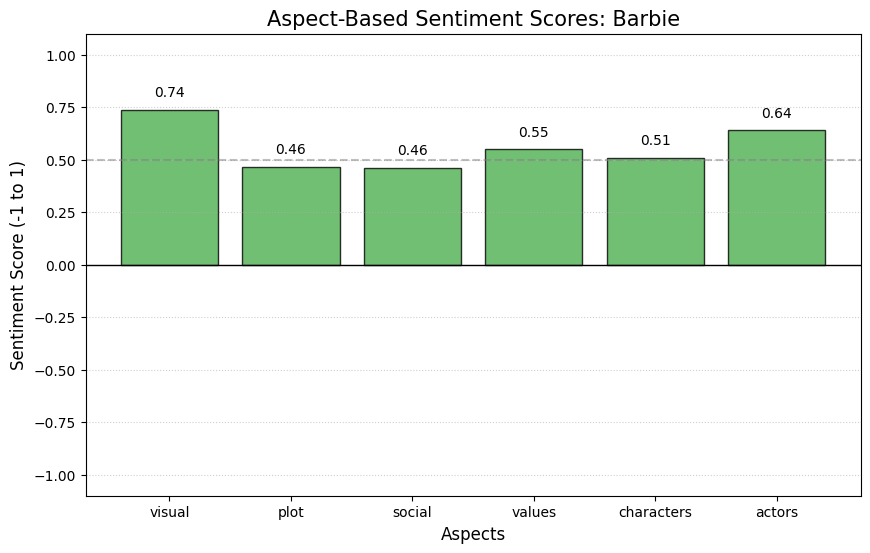

📊 Save as: /content/drive/MyDrive/Movie_project/plots/Oppenheimer_sentiment.png


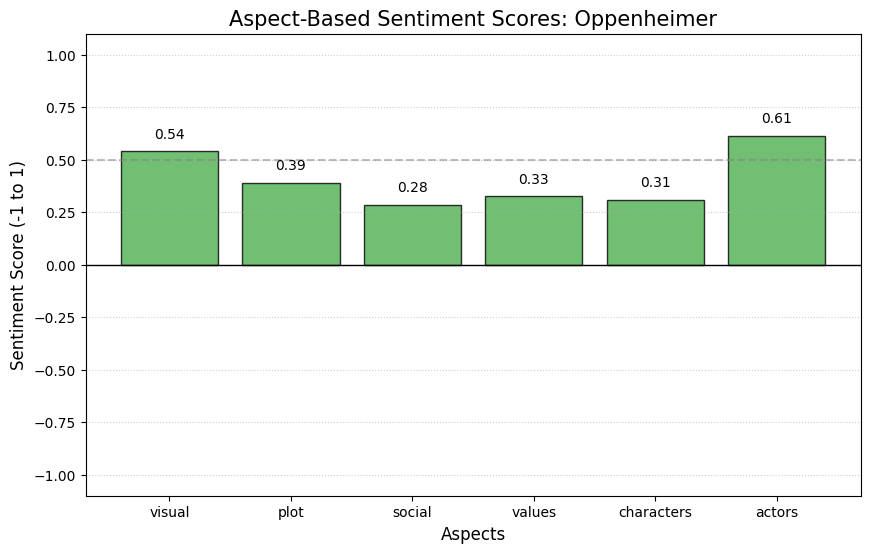

In [72]:
plot_movie_aspect_scores(barbie_scores, "Barbie", save_to_drive=True)

plot_movie_aspect_scores(oppen_scores, "Oppenheimer", save_to_drive=True)

In [73]:
def calculate_controversy_scores(final_result_dict, method='simple'):
    """

    method='simple': pos + neg
    method='balanced':
    """
    controversy_scores = {}

    for aspect, values in final_result_dict.items():
        pos = values['positive']
        neg = values['negative']

        if method == 'simple':
            score = pos + neg
        else:
            # 改进逻辑：讨论量大 且 正负比例接近
            # 如果正负相等，得分最高；如果一边倒，得分降低
            total_feedback = pos + neg
            balance = 1 - abs(pos - neg) / (total_feedback if total_feedback > 0 else 1)
            score = total_feedback * balance

        controversy_scores[aspect] = score

    return controversy_scores

In [74]:
final_result_barbie = summarize_movie_aspects(pos_aspect_barbie, neg_aspect_barbie, neu_aspect_barbie)
print(calculate_controversy_scores(final_result_barbie, method='simple'))

{'visual': 839, 'plot': 1610, 'social': 1366, 'values': 507, 'characters': 1028, 'actors': 857}


In [75]:
final_result_barbie = summarize_movie_aspects(pos_aspect_barbie, neg_aspect_barbie, neu_aspect_barbie)
print(calculate_controversy_scores(final_result_barbie, method='balanced'))

{'visual': 138.0, 'plot': 768.0, 'social': 635.9999999999999, 'values': 200.0, 'characters': 431.99999999999994, 'actors': 244.00000000000003}


In [76]:
final_result_oppen = summarize_movie_aspects(pos_aspect_oppen, neg_aspect_oppen, neu_aspect_oppen)
print(calculate_controversy_scores(final_result_oppen, method='simple'))

{'visual': 2274, 'plot': 4850, 'social': 534, 'values': 826, 'characters': 2146, 'actors': 3088}


In [77]:
final_result_oppen = summarize_movie_aspects(pos_aspect_oppen, neg_aspect_oppen, neu_aspect_oppen)
print(calculate_controversy_scores(final_result_oppen, method='balanced'))

{'visual': 880.0, 'plot': 2651.9999999999995, 'social': 354.00000000000006, 'values': 526.0, 'characters': 1366.0, 'actors': 945.9999999999999}


In [78]:
def plot_controversy_scores(controversy_scores, movie_name):
    aspects = list(controversy_scores.keys())
    scores = list(controversy_scores.values())

    plt.figure(figsize=(10, 6))
    plt.bar(aspects, scores, color='mediumpurple', edgecolor='black')

    plt.title(f"Aspect Controversy Level: {movie_name}", fontsize=15)
    plt.ylabel("Controversy Score (Volume + Balance)", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for i, v in enumerate(scores):
        plt.text(i, v + 0.1, round(v, 1), ha='center')

    plt.show()

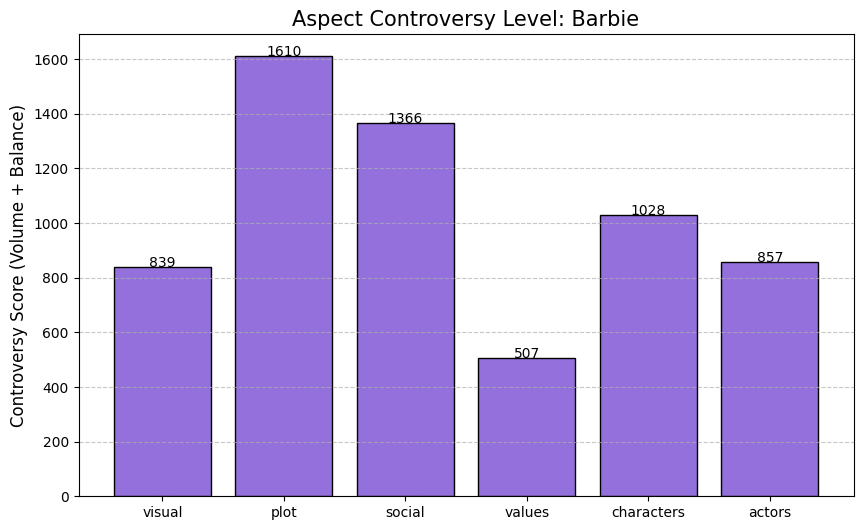

In [79]:
plot_controversy_scores(calculate_controversy_scores(final_result_barbie, method='simple'), "Barbie")

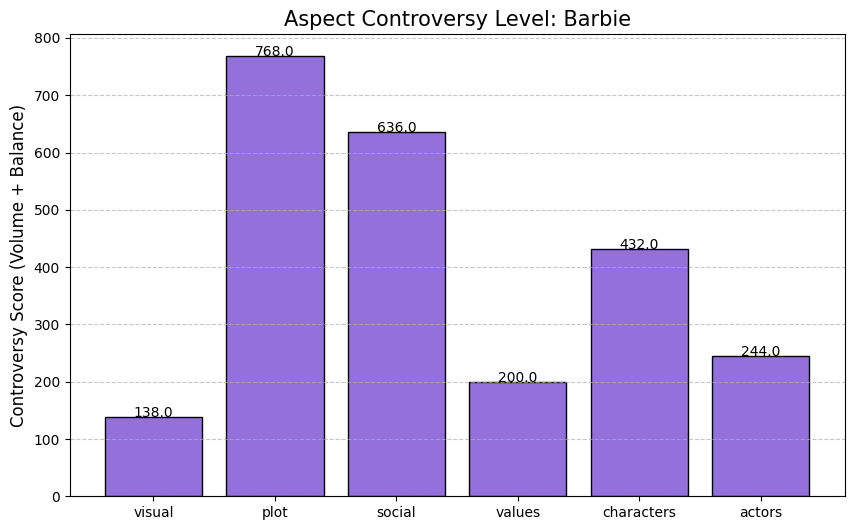

In [80]:
plot_controversy_scores(calculate_controversy_scores(final_result_barbie, method='balanced'), "Barbie")

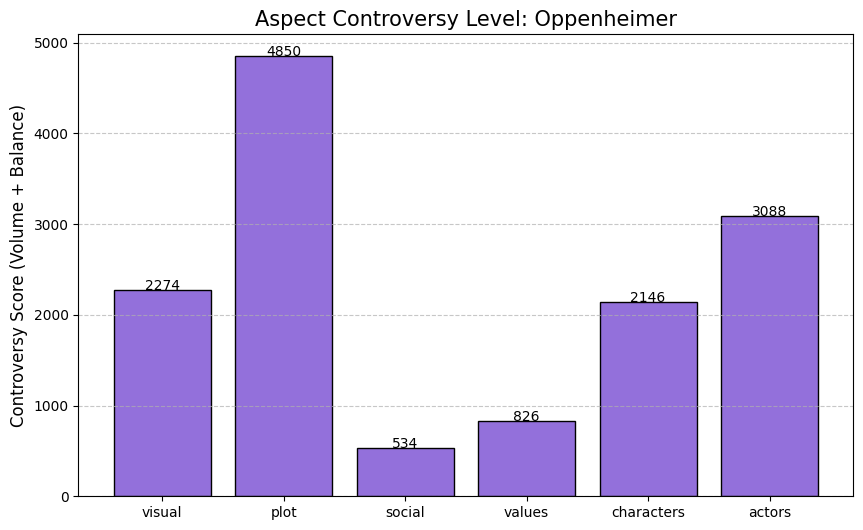

In [81]:
plot_controversy_scores(calculate_controversy_scores(final_result_oppen, method='simple'), "Oppenheimer")

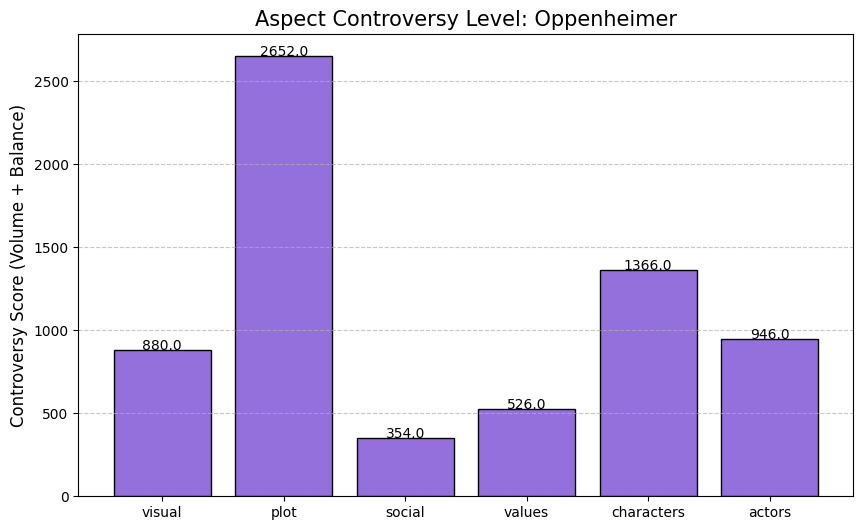

In [82]:
plot_controversy_scores(calculate_controversy_scores(final_result_oppen, method='balanced'), "Oppenheimer")

In [83]:
df_barbie_final['word_count'] = df_barbie_final['full_text'].apply(lambda x: len(x.split()))

df_barbie_long = df_barbie_final[df_barbie_final['word_count'] >= 15]

In [84]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words='english',
    min_df=5
)

X = vectorizer.fit_transform(df_barbie_long['full_text'])

bigram_freq = X.sum(axis=0)

bigram_df = pd.DataFrame({
    'phrase': vectorizer.get_feature_names_out(),
    'count': bigram_freq.tolist()[0]
})

bigram_df = bigram_df.sort_values(by='count', ascending=False)

bigram_df.head(100)

,phrase,count
1795,margot robbie,716
2498,ryan gosling,668
2387,real world,561
1269,greta gerwig,399
232,barbie movie,361
...,...,...
2399,really enjoyed,38
1944,movie does,37
3076,young girls,37
767,enjoyed movie,37


In [85]:
df_positive_barbie_long = df_barbie_long[df_barbie_long['category'] == "Positive"]
df_negative_barbie_long = df_barbie_long[df_barbie_long['category'] == "Negative"]

In [86]:
print(df_negative_barbie_long)

      score ipc-rating-star--maxRating  \
17      3.0                        /10   
20      3.0                        /10   
57      2.0                        /10   
87      3.0                        /10   
137     3.0                        /10   
...     ...                        ...   
2324    3.0                        /10   
2327    3.0                        /10   
2331    3.0                        /10   
2333    1.0                        /10   
2340    2.0                        /10   

                            ipc-title-link-wrapper href  \
17    https://www.imdb.com/title/tt1517268/review/rw...   
20    https://www.imdb.com/title/tt1517268/review/rw...   
57    https://www.imdb.com/title/tt1517268/review/rw...   
87    https://www.imdb.com/title/tt1517268/review/rw...   
137   https://www.imdb.com/title/tt1517268/review/rw...   
...                                                 ...   
2324  https://www.imdb.com/title/tt1517268/review/rw...   
2327  https://www.imdb.

In [87]:
gender_words = [
    "feminism",
    "feminist",
    "patriarchy",
    "gender",
    "anti men",
    "women rights",
    "female empowerment"
]

In [88]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

def analyze_gender_reviews(df, movie_name, gender_words, ngram_range=(2,2), top_n=10):

    df_gender = df[df["full_text"].str.contains('|'.join(gender_words), case=False, na=False)]

    print(f"\nMovie: {movie_name}")
    print("Gender related reviews:", len(df_gender))

    vectorizer = CountVectorizer(
        stop_words="english",
        ngram_range=ngram_range,
        min_df=3
    )

    X = vectorizer.fit_transform(df_gender["full_text"])

    counts = X.sum(axis=0).A1
    phrases = vectorizer.get_feature_names_out()

    ngram_df = pd.DataFrame({
        "phrase": phrases,
        "count": counts
    })

    # ⭐ only gender
    gender_pattern = '|'.join(gender_words)

    ngram_df = ngram_df[
        ngram_df["phrase"].str.contains(gender_pattern, case=False)
    ]

    ngram_df = ngram_df.sort_values(by="count", ascending=False)

    print("\nTop gender-related phrases:")
    print(ngram_df.head(top_n))

    return df_gender, ngram_df

In [89]:
barbie_gender, barbie_ngrams = analyze_gender_reviews(
    df_barbie_final,
    "Barbie",
    gender_words
)

oppen_gender, oppen_ngrams = analyze_gender_reviews(
    df_oppen_final,
    "Oppenheimer",
    gender_words
)


Movie: Barbie
Gender related reviews: 589

Top gender-related phrases:
                   phrase  count
978          gender roles     63
968       gender equality     30
760    female empowerment     30
779   feminism patriarchy     16
967       gender dynamics     14
1868  patriarchy feminism     14
1695       movie feminist     13
786      feminist message     12
438   commentary feminism      9
1874       patriarchy men      9

Movie: Oppenheimer
Gender related reviews: 8

Top gender-related phrases:
Empty DataFrame
Columns: [phrase, count]
Index: []


Chinese opinions in Douban

In [90]:
gender_cn = [
    "女",
    "男",
    "女性",
    "男性",
    "男人",
    "女人",
    "女权",
    "女性主义",
    "父权",
    "性别",
    "男女",
    "厌男",
    "厌女",
    "登"
]

In [91]:
import re
import jieba
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer


def analyze_douban_gender(df, movie_name, gender_words, top_n=100):

    df_gender = df[df["short"].str.contains('|'.join(gender_words), na=False)]

    print(f"\nMovie: {movie_name}")
    print("Gender related reviews:", len(df_gender))

    # 清理标点
    def clean_text(text):
        text = re.sub(r"[^\u4e00-\u9fa5]", " ", str(text))  # 只保留中文
        return text

    df_gender["clean_text"] = df_gender["short"].apply(clean_text)

    # 中文分词
    def chinese_tokenizer(text):
        return jieba.lcut(text)

    vectorizer = CountVectorizer(
        tokenizer=chinese_tokenizer,
        ngram_range=(2,2),
        min_df=2
    )

    X = vectorizer.fit_transform(df_gender["clean_text"])

    counts = X.sum(axis=0).A1
    phrases = vectorizer.get_feature_names_out()

    ngram_df = pd.DataFrame({
        "phrase": phrases,
        "count": counts
    })

    # ⭐ 只保留包含 gender 词的 phrase
    gender_pattern = '|'.join(gender_words)

    ngram_df = ngram_df[
        ngram_df["phrase"].str.contains(gender_pattern)
    ]

    ngram_df = ngram_df.sort_values(by="count", ascending=False)

    print("\nTop gender-related phrases:")
    print(ngram_df.head(top_n))

    return df_gender, ngram_df

/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning:

invalid escape sequence '\.'

/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning:

invalid escape sequence '\s'

/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning:

invalid escape sequence '\.'



In [92]:
df_barbie_cn = pd.read_csv("/content/drive/MyDrive/Movie_project/Barbie_fromtop.csv")
df_oppen_cn = pd.read_csv("/content/drive/MyDrive/Movie_project/Oppenheimer_fromtop.csv")

In [93]:
barbie_cn_gender, barbie_cn_ngram = analyze_douban_gender(
    df_barbie_cn,
    "Barbie (Douban)",
    gender_cn
)

oppen_cn_gender, oppen_cn_ngram = analyze_douban_gender(
    df_oppen_cn,
    "Oppenheimer (Douban)",
    gender_cn
)

Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...



Movie: Barbie (Douban)
Gender related reviews: 294


Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 0.624 seconds.
DEBUG:jieba:Loading model cost 0.624 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.



Top gender-related phrases:
     phrase  count
1469    男 的     44
859    女性 的     29
1541   的 女性     29
118      女性     23
841    女性       23
...     ...    ...
1861   被 女性      3
1596  的 父权制      3
1480  男性 凝视      3
1395  父权制 了      3
1473  男人 破防      3

[100 rows x 2 columns]

Movie: Oppenheimer (Douban)
Gender related reviews: 71

Top gender-related phrases:
    phrase  count
330    男 的     10
231  女性 角色      9
354   的 女性      8
329    男        7
335    白 男      7
363   的 男性      7
392   老白 男      7
227   女人        4
186    又 男      3
87      男主      3
228   女性        3
229  女性 形象      3
220    太 男      2
225    女 的      2
88      登月      2
49      女性      2
48       女      2
138  两位 女性      2
226  女 科学家      2
267  所有 女性      2
239   对 女性      2
230   女性 的      2
272   拍 男人      2
333  男性 角色      2
331   男人        2
332  男性 叙事      2
